In [1]:
print("Hola n Nameste")


Hola n Nameste


In [ ]:
import pandas as pd
df_actual = pd.read_csv('C:/Users/Priyanshu Bhatt/Desktop/Wind-Power/analysis/actual_wind_jan2024.csv')
df_forecast = pd.read_csv('C:/Users/Priyanshu Bhatt/Desktop/Wind-Power/analysis/forecast_wind_jan2024.csv')

In [10]:
display(df_actual.head())

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-02-01T00:00:00Z,2024-01-31T23:30:00Z,2024-01-31,48,WIND,14355
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31T23:00:00Z,2024-01-31,47,WIND,14595
2,FUELHH,2024-01-31T23:00:00Z,2024-01-31T22:30:00Z,2024-01-31,46,WIND,14908
3,FUELHH,2024-01-31T22:30:00Z,2024-01-31T22:00:00Z,2024-01-31,45,WIND,15490
4,FUELHH,2024-01-31T22:00:00Z,2024-01-31T21:30:00Z,2024-01-31,44,WIND,15719


In [11]:
display(df_forecast.head())

,dataset,publishTime,startTime,generation
0,WINDFOR,2024-01-31T22:30:00Z,2024-01-31T21:00:00Z,17543
1,WINDFOR,2024-01-31T22:30:00Z,2024-01-31T22:00:00Z,17315
2,WINDFOR,2024-01-31T22:30:00Z,2024-01-31T23:00:00Z,16909
3,WINDFOR,2024-01-31T22:30:00Z,2024-02-01T00:00:00Z,16341
4,WINDFOR,2024-01-31T22:30:00Z,2024-02-01T01:00:00Z,15630


In [12]:
#converting date and time to datetime obj to calculate the diff between publish time and start time
df_actual['startTime'] = pd.to_datetime(df_actual['startTime'])

df_forecast['startTime'] = pd.to_datetime(df_forecast['startTime'])
df_forecast['publishTime'] = pd.to_datetime(df_forecast['publishTime'])

In [13]:
#calculate the diff between the target time and when the prediction was made
time_difference = df_forecast['startTime'] - df_forecast['publishTime']
#convert that diff into total hours and save it into new coloumn
df_forecast['horizon_hours'] = time_difference.dt.total_seconds() / 3600

#look at the first few rows to verify
display(df_forecast[['publishTime', 'startTime', 'horizon_hours']].head())

,publishTime,startTime,horizon_hours
0,2024-01-31 22:30:00+00:00,2024-01-31 21:00:00+00:00,-1.5
1,2024-01-31 22:30:00+00:00,2024-01-31 22:00:00+00:00,-0.5
2,2024-01-31 22:30:00+00:00,2024-01-31 23:00:00+00:00,0.5
3,2024-01-31 22:30:00+00:00,2024-02-01 00:00:00+00:00,1.5
4,2024-01-31 22:30:00+00:00,2024-02-01 01:00:00+00:00,2.5


In [14]:
#check how many rows we started with
print(f"Original forcast rows: {len(df_forecast)}")

Original forcast rows: 12152


In [15]:
#apply 0-48 hours filter
df_forecast_filtered = df_forecast[
    (df_forecast['horizon_hours'] >= 0) & 
    (df_forecast['horizon_hours'] <= 48)
    ]
print(f"Filtered forcast rows: {len(df_forecast_filtered)}")

Filtered forcast rows: 9582


In [16]:
# Merge the filtered forecasts with the actual generation data
df_merged = pd.merge(
    df_forecast_filtered, 
    df_actual[['startTime', 'generation']], 
    on='startTime', 
    how='inner', 
    suffixes=('_forecast', '_actual')
)

# Look at the combined data
display(df_merged[['startTime', 'publishTime', 'horizon_hours', 'generation_forecast', 'generation_actual']].head())

,startTime,publishTime,horizon_hours,generation_forecast,generation_actual
0,2024-01-31 23:00:00+00:00,2024-01-31 22:30:00+00:00,0.5,16909,14595
1,2024-01-31 21:00:00+00:00,2024-01-31 18:30:00+00:00,2.5,17912,15757
2,2024-01-31 22:00:00+00:00,2024-01-31 18:30:00+00:00,3.5,17670,15490
3,2024-01-31 23:00:00+00:00,2024-01-31 18:30:00+00:00,4.5,17275,14595
4,2024-01-31 21:00:00+00:00,2024-01-31 15:30:00+00:00,5.5,17887,15757


In [17]:
# Calculate raw error (Guess - Truth)
df_merged['error'] = df_merged['generation_forecast'] - df_merged['generation_actual']

# Calculate absolute error
df_merged['abs_error'] = df_merged['error'].abs()

In [18]:
# Calculate the metrics
mean_error = df_merged['abs_error'].mean()
median_error = df_merged['abs_error'].median()
p99_error = df_merged['abs_error'].quantile(0.99)

print(f"Mean Error: {mean_error:.2f} MW")
print(f"Median Error: {median_error:.2f} MW")
print(f"99th Percentile (p99) Error: {p99_error:.2f} MW")

Mean Error: 2071.51 MW
Median Error: 1806.50 MW
99th Percentile (p99) Error: 7189.41 MW


In [19]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 181.3 kB/s eta 0:00:43
   -- ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


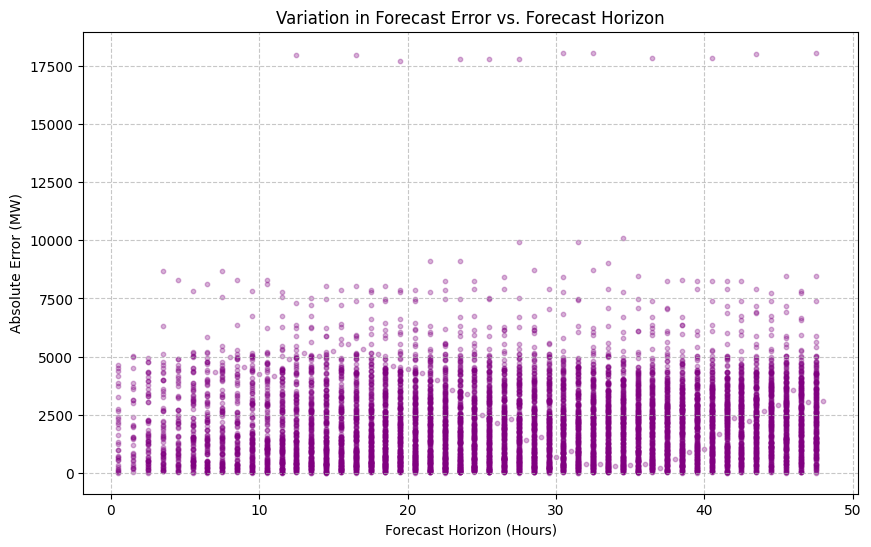

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Create a scatter plot
plt.scatter(df_merged['horizon_hours'], df_merged['abs_error'], alpha=0.3, color='purple', s=10)

plt.title('Variation in Forecast Error vs. Forecast Horizon')
plt.xlabel('Forecast Horizon (Hours)')
plt.ylabel('Absolute Error (MW)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [22]:
#Analysis of Forecast Error vs Horizon:
#Based on the scatter plot above, the forecast model exhibits a consistent baseline error mostly concentrated between 0 and 5,000 MW across all time horizons. Surprisingly, the model's accuracy does not degrade significantly as the forecast horizon extends from 0 to 48 hours; the error distribution remains relatively horizontal.

#However, the model is highly vulnerable to extreme outlier events. We can observe severe prediction errors exceeding 17,500 MW occurring across various time horizons. This implies that while the model handles standard day-to-day wind fluctuations reasonably well, it likely fails to anticipate sudden, severe weather anomalies, which would require grid operators to maintain significant backup power reserves.

In [23]:
# Focusing strictly on the historical actual generation
actual_gen = df_actual['generation']

# Calculating key percentiles (0.01 = 1st percentile, 0.50 = median)
reliability_metrics = actual_gen.quantile([0.0, 0.01, 0.05, 0.10, 0.25, 0.50])

print("--- Historical Wind Power Reliability ---")
print(f"Absolute Minimum (0%): {reliability_metrics[0.0]:.2f} MW")
print(f"P01 (Available 99% of the time): {reliability_metrics[0.01]:.2f} MW")
print(f"P05 (Available 95% of the time): {reliability_metrics[0.05]:.2f} MW")
print(f"P10 (Available 90% of the time): {reliability_metrics[0.10]:.2f} MW")
print(f"Median (Available 50% of the time): {reliability_metrics[0.50]:.2f} MW")

--- Historical Wind Power Reliability ---
Absolute Minimum (0%): 0.00 MW
P01 (Available 99% of the time): 3233.58 MW
P05 (Available 95% of the time): 4301.10 MW
P10 (Available 90% of the time): 5087.90 MW
Median (Available 50% of the time): 9863.50 MW


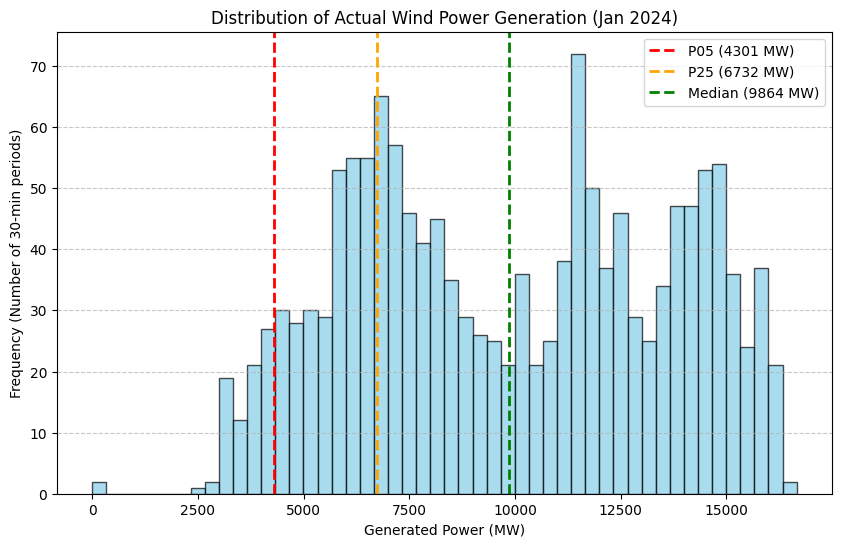

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Ploting a histogram of the actual generation
plt.hist(actual_gen, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Adding vertical lines for our key percentiles
plt.axvline(reliability_metrics[0.05], color='red', linestyle='dashed', linewidth=2, label=f'P05 ({reliability_metrics[0.05]:.0f} MW)')
plt.axvline(reliability_metrics[0.25], color='orange', linestyle='dashed', linewidth=2, label=f'P25 ({reliability_metrics[0.25]:.0f} MW)')
plt.axvline(reliability_metrics[0.50], color='green', linestyle='dashed', linewidth=2, label=f'Median ({reliability_metrics[0.50]:.0f} MW)')

plt.title('Distribution of Actual Wind Power Generation (Jan 2024)')
plt.xlabel('Generated Power (MW)')
plt.ylabel('Frequency (Number of 30-min periods)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
#Reliability Recommendation:
#Wind power generation is highly volatile. While the median generation for January 2024 was 9,864 MW, relying on this figure would mean the grid faces a massive power deficit 50% of the time.

#To guarantee grid stability, I recommend planning for the 5th percentile (P05) threshold, which is 4,301 MW. Statistically, the UK wind grid generates at least this much power 95% of the time. Any expected demand above this 4,301 MW baseline should be supplemented by more controllable energy sources or backed by significant battery storage reserves. Planning for a higher threshold (like the P25 mark of 6,732 MW) would be too optimistic and carry an unacceptable risk of blackouts during low-wind periods.